# Modeling Heart Disease Dataset

Notebook ini berisi tahapan modeling dataset Heart Disease menggunakan Logistic Regression, meliputi:

1. Load Libraries
2. Load Processed Data
3. Splitting Dataset (80:20)
4. Logistic Regression Modeling (GridSearchCV)
5. Odds Ratio Analysis (statsmodels, dengan reference categories)
6. Evaluation: Predictions & Metrics
7. Metrics Summary
8. Classification Reports
9. Visualizations
10. Save Results & Models

## 1. Load Libraries

In [54]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, cohen_kappa_score,
    classification_report
)
from scipy.stats import gmean
import statsmodels.api as sm
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Load Processed Data

In [55]:
# Load Processed Data
df = pd.read_csv('Data/heart_cleaned.csv')
print(f"Data shape: {df.shape}")

# Separate features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}\n")

# Splitting Dataset 80:20
print("="*50)

Data shape: (918, 19)
Features shape: (918, 18)
Target shape: (918,)
Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64



## 3. Logistic Regression Modeling

In [56]:
# Train Logistic Regression as a baseline comparison model
print("="*50)
print("LOGISTIC REGRESSION MODEL")
print("="*50)

logreg_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

print("Logistic Regression Parameter Grid:")
for key, value in logreg_param_grid.items():
    print(f"  {key}: {value}")

logreg_base = LogisticRegression(random_state=42, max_iter=1000)
logreg_grid_search = GridSearchCV(
    logreg_base,
    logreg_param_grid,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nTraining Logistic Regression with GridSearchCV (5-Fold CV)...")
logreg_grid_search.fit(X_cv, y_cv)

best_logreg_model = logreg_grid_search.best_estimator_
best_logreg_params = logreg_grid_search.best_params_

print(f"\nBest Logistic Regression Parameters Found:")
for key, value in best_logreg_params.items():
    print(f"  {key}: {value}")
print(f"Best CV ROC-AUC Score: {logreg_grid_search.best_score_:.4f}\n")

LOGISTIC REGRESSION MODEL
Logistic Regression Parameter Grid:
  C: [0.1, 1, 10]
  solver: ['liblinear']

Training Logistic Regression with GridSearchCV (5-Fold CV)...
Fitting 10 folds for each of 3 candidates, totalling 30 fits

Best Logistic Regression Parameters Found:
  C: 1
  solver: liblinear
Best CV ROC-AUC Score: 0.9164



## 4. Odds Ratio Analysis

Reference categories (dummy variable trap avoidance):
- **ChestPainType** → `ASY` (Asymptomatic)
- **RestingECG** → `Normal`
- **ST_Slope** → `Up` (Normal slope)

In [57]:
# Fit a statsmodels logistic regression for odds ratio interpretation
print("="*50)
print("ODDS RATIO ANALYSIS (statsmodels)")
print("="*50)

# --- Drop 1 reference category per multiclass dummy feature ---
# This avoids the dummy variable trap (multicollinearity) so statsmodels
# can invert the design matrix without producing NaN / inf coefficients.
reference_categories = {
    'ChestPainType': 'ASY',   # Asymptomatic → baseline
    'RestingECG':    'Normal', # Normal ECG   → baseline
    'ST_Slope':      'Up',     # Normal slope → baseline
}

cols_to_drop = []
for feat, ref in reference_categories.items():
    col_name = f"{feat}_{ref}"
    if col_name in X_cv.columns:
        cols_to_drop.append(col_name)
        print(f"  Reference: {col_name}")
    else:
        print(f"  [SKIP] Column {col_name} not found — already absent")

print(f"\nDropped {len(cols_to_drop)} reference column(s): {cols_to_drop}\n")

X_cv_or = X_cv.drop(columns=cols_to_drop)
X_cv_or = sm.add_constant(X_cv_or.astype(float), has_constant='add')
logit_sm = sm.Logit(y_cv, X_cv_or).fit(disp=False)

conf_int = logit_sm.conf_int()
odds_ratio_df = pd.DataFrame({
    'Feature': X_cv_or.columns[1:],       # exclude constant
    'Coefficient': logit_sm.params.iloc[1:].values,
    'Odds_Ratio': np.exp(logit_sm.params.iloc[1:].values),
    'CI_Lower': np.exp(conf_int.iloc[1:, 0].values),
    'CI_Upper': np.exp(conf_int.iloc[1:, 1].values),
    'P_Value': logit_sm.pvalues.iloc[1:].values
})

odds_ratio_df = odds_ratio_df.sort_values('P_Value').reset_index(drop=True)
print(odds_ratio_df.to_string(index=False))

significant_features = odds_ratio_df[odds_ratio_df['P_Value'] < 0.05]
if not significant_features.empty:
    print("\nSignificant predictors (p < 0.05):")
    print(significant_features.to_string(index=False))

odds_ratio_df.to_csv('outputs/logistic_regression_odds_ratio.csv', index=False)
print("\n[OK] Saved: outputs/logistic_regression_odds_ratio.csv")

ODDS RATIO ANALYSIS (statsmodels)
  Reference: ChestPainType_ASY
  Reference: RestingECG_Normal
  Reference: ST_Slope_Up

Dropped 3 reference column(s): ['ChestPainType_ASY', 'RestingECG_Normal', 'ST_Slope_Up']

          Feature  Coefficient  Odds_Ratio  CI_Lower  CI_Upper      P_Value
    ST_Slope_Flat     2.454063   11.635530  6.830676 19.820228 1.712617e-19
ChestPainType_NAP    -1.826642    0.160953  0.090145  0.287380 6.576537e-10
ChestPainType_ATA    -1.775617    0.169379  0.084524  0.339420 5.537396e-07
              Sex     1.434031    4.195576  2.282468  7.712203 3.895039e-06
        FastingBS     1.306814    3.694384  2.029232  6.725931 1.912606e-05
 ChestPainType_TA    -1.484776    0.226553  0.092678  0.553812 1.131064e-03
   ExerciseAngina     0.839674    2.315613  1.369770  3.914573 1.721260e-03
    ST_Slope_Down     1.572366    4.818032  1.625816 14.278019 4.556733e-03
         HR_Ratio    -0.249796    0.778960  0.606368  1.000676 5.062148e-02
          Oldpeak     0.2350

## 5. Evaluation: Predictions & Metrics

In [58]:
# EVALUATE: Make predictions on CV and test data
# Logistic Regression predictions
y_pred_cv_lr = best_logreg_model.predict(X_cv)
y_pred_proba_cv_lr = best_logreg_model.predict_proba(X_cv)[:, 1]

y_pred_test_lr = best_logreg_model.predict(X_test)
y_pred_proba_test_lr = best_logreg_model.predict_proba(X_test)[:, 1]

# Function to calculate metrics
def calculate_metrics(y_true, y_pred, y_pred_proba, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    # Calculate Specificity and G-Mean
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall/Sensitivity
    tnr = specificity  # Specificity
    g_mean = gmean([tpr, tnr])
    
    cm = confusion_matrix(y_true, y_pred)
    
    metrics_dict = {
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Kappa': kappa,
        'G-Mean': g_mean,
        'Confusion_Matrix': cm
    }
    
    return metrics_dict

# Calculate metrics for both datasets
metrics_cv_lr = calculate_metrics(y_cv, y_pred_cv_lr, y_pred_proba_cv_lr, 'CV (Train)')
metrics_test_lr = calculate_metrics(y_test, y_pred_test_lr, y_pred_proba_test_lr, 'Test (Blind)')

## 6. Metrics Summary

In [59]:
# Display metrics
print("\n" + "="*50)
print("METRICS SUMMARY")
print("="*50)

lr_metrics_summary = pd.DataFrame([
    {
        'Dataset': 'CV (Train)',
        'Accuracy': f"{metrics_cv_lr['Accuracy']:.4f}",
        'Precision': f"{metrics_cv_lr['Precision']:.4f}",
        'Recall': f"{metrics_cv_lr['Recall']:.4f}",
        'Specificity': f"{metrics_cv_lr['Specificity']:.4f}",
        'F1-Score': f"{metrics_cv_lr['F1-Score']:.4f}",
        'Kappa': f"{metrics_cv_lr['Kappa']:.4f}",
        'G-Mean': f"{metrics_cv_lr['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_cv_lr['ROC-AUC']:.4f}"
    },
    {
        'Dataset': 'Test (Blind)',
        'Accuracy': f"{metrics_test_lr['Accuracy']:.4f}",
        'Precision': f"{metrics_test_lr['Precision']:.4f}",
        'Recall': f"{metrics_test_lr['Recall']:.4f}",
        'Specificity': f"{metrics_test_lr['Specificity']:.4f}",
        'F1-Score': f"{metrics_test_lr['F1-Score']:.4f}",
        'Kappa': f"{metrics_test_lr['Kappa']:.4f}",
        'G-Mean': f"{metrics_test_lr['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_test_lr['ROC-AUC']:.4f}"
    }
])

print("\nLogistic Regression Metrics")
print(lr_metrics_summary.to_string(index=False))


METRICS SUMMARY

Logistic Regression Metrics
     Dataset Accuracy Precision Recall Specificity F1-Score  Kappa G-Mean ROC-AUC
  CV (Train)   0.8597    0.8651 0.8842      0.8293   0.8745 0.7154 0.8563  0.9283
Test (Blind)   0.8913    0.8868 0.9216      0.8537   0.9038 0.7790 0.8870  0.9317


## 7. Classification Reports

In [60]:
# Classification Reports
print("\n" + "="*50)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION - CV (TRAIN)")
print("="*50)
print(classification_report(y_cv, y_pred_cv_lr, target_names=['No Disease', 'Has Disease']))

print("\n" + "="*50)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION - TEST (BLIND)")
print("="*50)
print(classification_report(y_test, y_pred_test_lr, target_names=['No Disease', 'Has Disease']))


CLASSIFICATION REPORT - LOGISTIC REGRESSION - CV (TRAIN)
              precision    recall  f1-score   support

  No Disease       0.85      0.83      0.84       328
 Has Disease       0.87      0.88      0.87       406

    accuracy                           0.86       734
   macro avg       0.86      0.86      0.86       734
weighted avg       0.86      0.86      0.86       734


CLASSIFICATION REPORT - LOGISTIC REGRESSION - TEST (BLIND)
              precision    recall  f1-score   support

  No Disease       0.90      0.85      0.88        82
 Has Disease       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



## 8. Visualizations


GENERATING VISUALIZATIONS


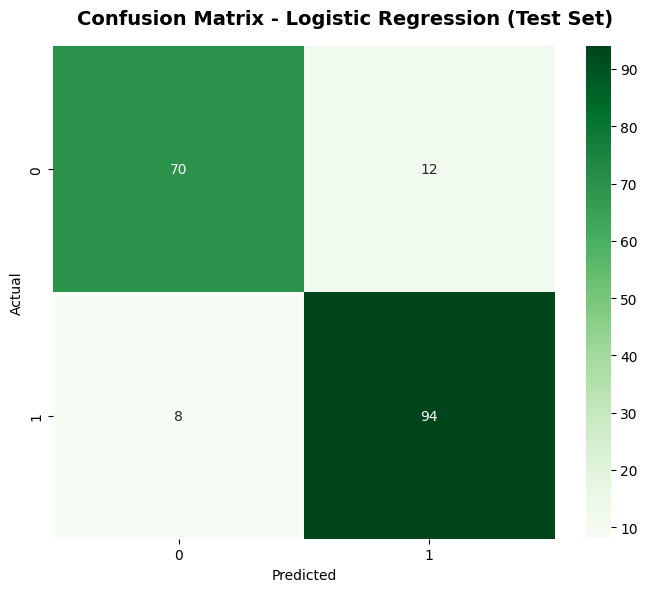

[OK] Saved: outputs/LRconfusion_matrix.png


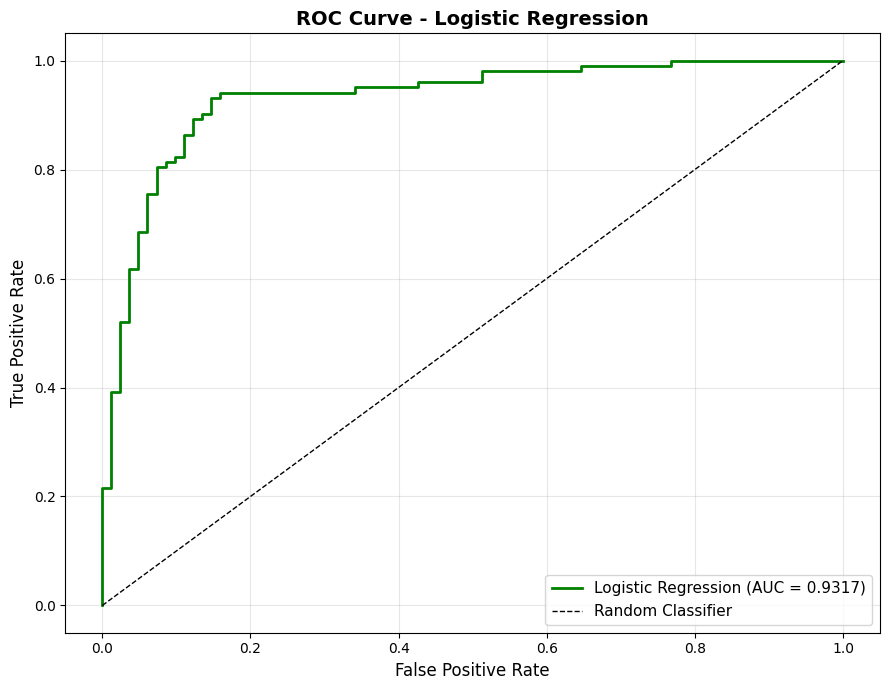

[OK] Saved: outputs/LRroc_curve.png


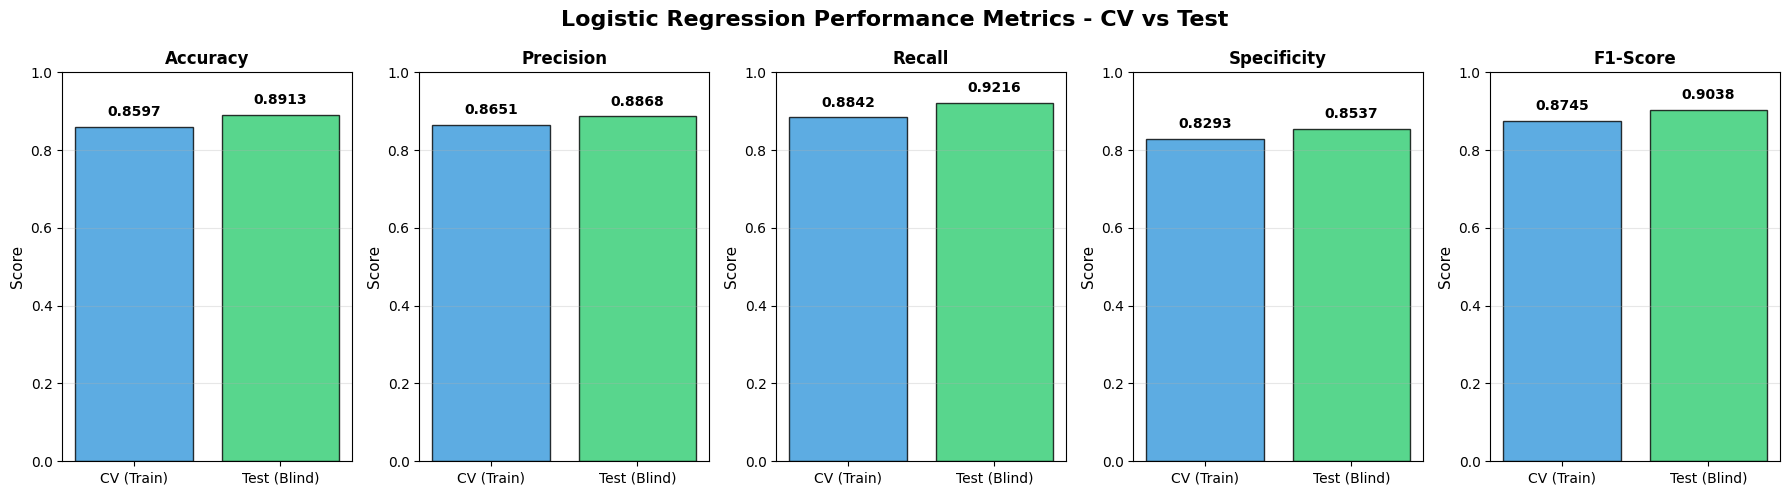

[OK] Saved: outputs/LRmetrics.png


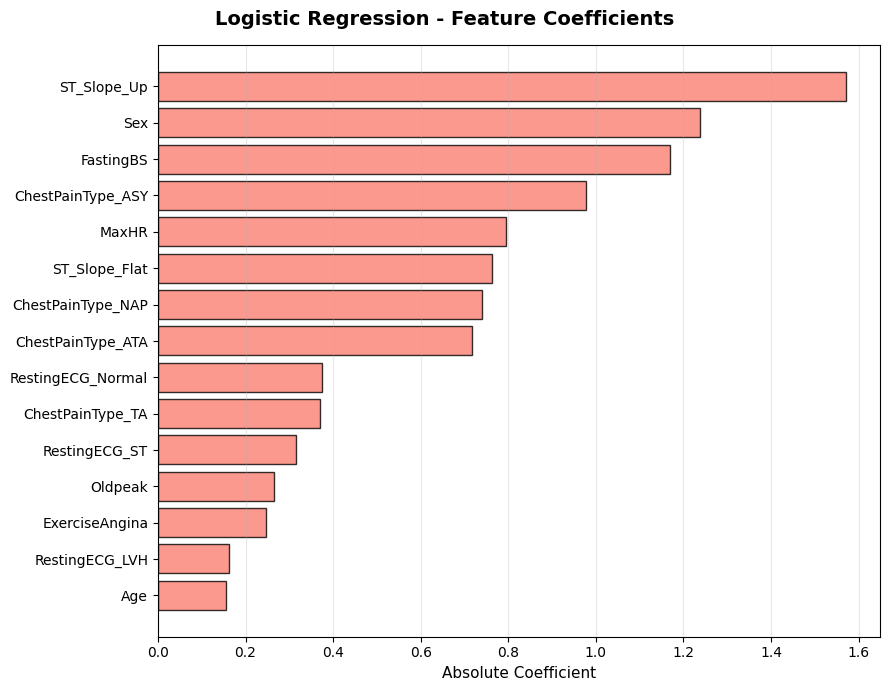

[OK] Saved: outputs/LRfeature_importance.png


In [61]:
# VISUALIZATIONS
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# 1. Confusion Matrix for Logistic Regression (Test Set)
fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Confusion Matrix - Logistic Regression (Test Set)', fontsize=14, fontweight='bold')

cm_lr_test = confusion_matrix(y_test, y_pred_test_lr)

sns.heatmap(cm_lr_test, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/LRconfusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: outputs/LRconfusion_matrix.png")

# 2. ROC Curve for Logistic Regression (Test Set)
fig, ax = plt.subplots(figsize=(9, 7))

fpr_lr_test, tpr_lr_test, _ = roc_curve(y_test, y_pred_proba_test_lr)
roc_auc_lr_test = roc_auc_score(y_test, y_pred_proba_test_lr)

ax.plot(fpr_lr_test, tpr_lr_test, label=f'Logistic Regression (AUC = {roc_auc_lr_test:.4f})', linewidth=2, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/LRroc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: outputs/LRroc_curve.png")

# 3. Metrics Comparison Bar Plot (CV vs Test)
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Logistic Regression Performance Metrics - CV vs Test', fontsize=16, fontweight='bold')

metrics_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
datasets = ['CV (Train)', 'Test (Blind)']
colors_bars = ['#3498db', '#2ecc71']

for idx, metric_name in enumerate(metrics_names):
    ax = axes[idx]
    
    metric_key = metric_name.replace(' ', '_').replace('-', '_')
    if metric_key == 'F1_Score':
        metric_key = 'F1-Score'
    
    cv_value = metrics_cv_lr[metric_key]
    test_value = metrics_test_lr[metric_key]
    
    bars = ax.bar(datasets, [cv_value, test_value], color=colors_bars, alpha=0.8, edgecolor='black')
    
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{metric_name}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, axis='y', alpha=0.3)
    
    for bar, value in zip(bars, [cv_value, test_value]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/LRmetrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: outputs/LRmetrics.png")

# 4. Logistic Regression Coefficients
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Logistic Regression - Feature Coefficients', fontsize=14, fontweight='bold')

feature_names = X.columns

logreg_coefficients = np.abs(best_logreg_model.coef_[0])
logreg_indices = np.argsort(logreg_coefficients)[-15:]
ax.barh(range(len(logreg_indices)), logreg_coefficients[logreg_indices], color='salmon', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(logreg_indices)))
ax.set_yticklabels([feature_names[i] for i in logreg_indices], fontsize=10)
ax.set_xlabel('Absolute Coefficient', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/LRfeature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: outputs/LRfeature_importance.png")

## 9. Save Results & Models

In [62]:
# SAVE RESULTS AND MODEL
print("\n" + "="*50)
print("SAVING RESULTS & MODEL")
print("="*50)

# Save comprehensive metrics report
metrics_report = {
    'LogisticRegression': {
        'CV (Train)': {
            'Accuracy': metrics_cv_lr['Accuracy'],
            'Precision': metrics_cv_lr['Precision'],
            'Recall': metrics_cv_lr['Recall'],
            'Specificity': metrics_cv_lr['Specificity'],
            'F1-Score': metrics_cv_lr['F1-Score'],
            'Kappa': metrics_cv_lr['Kappa'],
            'G-Mean': metrics_cv_lr['G-Mean'],
            'ROC-AUC': metrics_cv_lr['ROC-AUC']
        },
        'Test (Blind)': {
            'Accuracy': metrics_test_lr['Accuracy'],
            'Precision': metrics_test_lr['Precision'],
            'Recall': metrics_test_lr['Recall'],
            'Specificity': metrics_test_lr['Specificity'],
            'F1-Score': metrics_test_lr['F1-Score'],
            'Kappa': metrics_test_lr['Kappa'],
            'G-Mean': metrics_test_lr['G-Mean'],
            'ROC-AUC': metrics_test_lr['ROC-AUC']
        }
    }
}

metrics_df = pd.DataFrame(metrics_report).T
metrics_df.to_csv('outputs/LRmodel_results.csv')
print("[OK] Saved: outputs/LRmodel_results.csv")

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'LogisticRegression_Predicted': y_pred_test_lr,
    'LogisticRegression_Probability_Class_0': 1 - y_pred_proba_test_lr,
    'LogisticRegression_Probability_Class_1': y_pred_proba_test_lr
})
predictions_df.to_csv('outputs/best_LRmodel_predictions.csv', index=False)
print("[OK] Saved: outputs/best_LRmodel_predictions.csv")

# Save best Logistic Regression model
joblib.dump(best_logreg_model, 'outputs/best_LRmodel.pkl')
print("[OK] Saved: outputs/best_LRmodel.pkl")

# Save best parameters and GridSearch info
gridsearch_info = {
    'logistic_regression': {
        'best_params': best_logreg_params,
        'best_cv_score': logreg_grid_search.best_score_,
        'cv_results': logreg_grid_search.cv_results_
    }
}
joblib.dump(gridsearch_info, 'outputs/LRgridsearch_info.pkl')
print("[OK] Saved: outputs/LRgridsearch_info.pkl")

# Save y_test and y_probs for ROC Curve
evaluation_data = {
    'y_test': y_test,
    'logistic_regression_probs': y_pred_proba_test_lr
}
joblib.dump(evaluation_data, 'outputs/LRmodel_eval_data.pkl')

print("\n" + "="*50)
print("MODELING COMPLETE!")
print("="*50)
print(f"Best Logistic Regression Parameters: {best_logreg_params}")
print(f"\nTest Set Performance:")
print(f"  Logistic Regression Accuracy: {metrics_test_lr['Accuracy']:.4f}")
print(f"  Logistic Regression ROC-AUC: {metrics_test_lr['ROC-AUC']:.4f}")
print(f"  Logistic Regression Recall: {metrics_test_lr['Recall']:.4f}")
print(f"  Logistic Regression Specificity: {metrics_test_lr['Specificity']:.4f}")
print(f"  Logistic Regression F1-Score: {metrics_test_lr['F1-Score']:.4f}")
print(f"  Logistic Regression G-Mean: {metrics_test_lr['G-Mean']:.4f}")


SAVING RESULTS & MODEL
[OK] Saved: outputs/LRmodel_results.csv
[OK] Saved: outputs/best_LRmodel_predictions.csv
[OK] Saved: outputs/best_LRmodel.pkl
[OK] Saved: outputs/LRgridsearch_info.pkl

MODELING COMPLETE!
Best Logistic Regression Parameters: {'C': 1, 'solver': 'liblinear'}

Test Set Performance:
  Logistic Regression Accuracy: 0.8913
  Logistic Regression ROC-AUC: 0.9317
  Logistic Regression Recall: 0.9216
  Logistic Regression Specificity: 0.8537
  Logistic Regression F1-Score: 0.9038
  Logistic Regression G-Mean: 0.8870
